In [1]:
# ============================================
# 1. БАЗОВЫЕ БИБЛИОТЕКИ
# ============================================
import numpy as np
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 2. ВИЗУАЛИЗАЦИЯ
# ============================================
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
%matplotlib inline

# ============================================
# 3. ПРЕДОБРАБОТКА
# ============================================
from sklearn.preprocessing import LabelEncoder

# ============================================
# 4. МОДЕЛЬ
# ============================================
from sklearn.ensemble import RandomForestClassifier

# ============================================
# 5. ОЦЕНКА
# ============================================
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# ============================================
# 6. BASELINE СРАВНЕНИЕ
# ============================================
from sklearn.linear_model import LogisticRegression

# ============================================
# 7. НАСТРОЙКИ ОТОБРАЖЕНИЯ
# ============================================
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [2]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')


In [3]:
print("=== ПРОПУСКИ В TRAIN ===")
missing_train = pd.DataFrame({
    'Пропусков': train_df.isnull().sum(),
    'Процент %': (train_df.isnull().sum() / len(train_df) * 100).round(2)
}).sort_values('Процент %', ascending=False)

print(missing_train[missing_train['Пропусков'] > 0])

print("\n=== ПРОПУСКИ В TEST ===")
missing_test = pd.DataFrame({
    'Пропусков': test_df.isnull().sum(),
    'Процент %': (test_df.isnull().sum() / len(test_df) * 100).round(2)
}).sort_values('Процент %', ascending=False)

print(missing_test[missing_test['Пропусков'] > 0])

=== ПРОПУСКИ В TRAIN ===
          Пропусков  Процент %
Cabin           687      77.10
Age             177      19.87
Embarked          2       0.22

=== ПРОПУСКИ В TEST ===
       Пропусков  Процент %
Cabin        327      78.23
Age           86      20.57
Fare           1       0.24


In [4]:
test_passenger_ids = test_df['PassengerId'].copy()

# Сохраняем целевую переменную:
y_train = train_df['Survived'].copy()

# Объединяем для единой предобработки:
full_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")
print(f"Full: {full_df.shape}")

Train: (891, 12)
Test: (418, 11)
Full: (1309, 12)


In [5]:
full_df['Title'] = full_df['Name'].str.extract(r'([A-Za-z]+)\.')

# Редкие титулы объединяем:
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don',
               'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
full_df['Title'] = full_df['Title'].replace(rare_titles, 'Rare')
full_df['Title'] = full_df['Title'].replace({'Mlle': 'Miss',
                                              'Ms': 'Miss',
                                              'Mme': 'Mrs'})

print(full_df['Title'].value_counts())

Title
Mr        757
Miss      264
Mrs       198
Master     61
Rare       29
Name: count, dtype: int64


In [6]:
# 2. Размер семьи:
full_df['FamilySize'] = full_df['SibSp'] + full_df['Parch'] + 1

# 3. Один или нет:
full_df['IsAlone'] = (full_df['FamilySize'] == 1).astype(int)

# 4. Наличие каюты (твой инсайт из EDA!):
full_df['Has_Cabin'] = full_df['Cabin'].notna().astype(int)

# 5. Палуба из номера каюты:
full_df['Deck'] = full_df['Cabin'].str.extract(r'([A-Za-z])')
full_df['Deck'] = full_df['Deck'].fillna('Unknown')

print(full_df['FamilySize'].value_counts())
print(full_df['IsAlone'].value_counts())
print(full_df['Has_Cabin'].value_counts())

FamilySize
1     790
2     235
3     159
4      43
6      25
5      22
7      16
11     11
8       8
Name: count, dtype: int64
IsAlone
1    790
0    519
Name: count, dtype: int64
Has_Cabin
0    1014
1     295
Name: count, dtype: int64


In [7]:
# train часть = первые 891 строк
train_part = full_df[:891]

# Embarked — мода только по train:
embarked_mode = train_part['Embarked'].mode()[0]
full_df['Embarked'] = full_df['Embarked'].fillna(embarked_mode)
print(f"Embarked заполнен: {embarked_mode}")

# Fare — медиана по Pclass только по train:
fare_median_by_class = train_part.groupby('Pclass')['Fare'].median()
print(f"\nМедиана Fare по классам:\n{fare_median_by_class}")

def fill_fare(row):
    if pd.isna(row['Fare']):
        return fare_median_by_class[row['Pclass']]
    return row['Fare']

full_df['Fare'] = full_df.apply(fill_fare, axis=1)

# Age — медиана по Title + Pclass только по train:
age_median = train_part.groupby(['Title', 'Pclass'])['Age'].median()
print(f"\nМедиана Age по Title+Pclass:\n{age_median}")

def fill_age(row):
    if pd.isna(row['Age']):
        try:
            return age_median[row['Title'], row['Pclass']]
        except KeyError:
            return train_part['Age'].median()
    return row['Age']

full_df['Age'] = full_df.apply(fill_age, axis=1)

# Проверка:
print("\nПропуски после заполнения:")
print(full_df[['Age', 'Embarked', 'Fare']].isnull().sum())

Embarked заполнен: S

Медиана Fare по классам:
Pclass
1    60.2875
2    14.2500
3     8.0500
Name: Fare, dtype: float64

Медиана Age по Title+Pclass:
Title   Pclass
Master  1          4.0
        2          1.0
        3          4.0
Miss    1         30.0
        2         24.0
        3         18.0
Mr      1         40.0
        2         31.0
        3         26.0
Mrs     1         40.0
        2         32.0
        3         31.0
Rare    1         48.5
        2         46.5
Name: Age, dtype: float64

Пропуски после заполнения:
Age         0
Embarked    0
Fare        0
dtype: int64


In [8]:

le = LabelEncoder()

# Кодируем категориальные признаки:
categorical_cols = ['Sex', 'Embarked', 'Title', 'Deck']

for col in categorical_cols:
    full_df[col] = le.fit_transform(full_df[col].astype(str))
    print(f"{col}: {full_df[col].unique()}")

print("\nТипы данных после кодирования:")
print(full_df[categorical_cols].dtypes)

Sex: [1 0]
Embarked: [2 0 1]
Title: [2 3 1 0 4]
Deck: [8 2 4 6 3 0 1 5 7]

Типы данных после кодирования:
Sex         int64
Embarked    int64
Title       int64
Deck        int64
dtype: object


In [9]:

# Колонки которые удаляем:
drop_cols = ['PassengerId', 'Name', 'Ticket', 
             'Cabin', 'SibSp', 'Parch']

full_df = full_df.drop(columns=drop_cols)

print("Оставшиеся признаки:")
print(full_df.columns.tolist())
print(f"\nРазмер: {full_df.shape}")

Оставшиеся признаки:
['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'Has_Cabin', 'Deck']

Размер: (1309, 11)


In [10]:
# Разделяем обратно на train и test:
X_train = full_df[:891].drop(columns=['Survived'])
X_test = full_df[891:].drop(columns=['Survived'])

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")

# Финальная проверка пропусков:
print("\nПропуски в X_train:")
print(X_train.isnull().sum())
print("\nПропуски в X_test:")
print(X_test.isnull().sum())

X_train: (891, 10)
X_test: (418, 10)
y_train: (891,)

Пропуски в X_train:
Pclass        0
Sex           0
Age           0
Fare          0
Embarked      0
Title         0
FamilySize    0
IsAlone       0
Has_Cabin     0
Deck          0
dtype: int64

Пропуски в X_test:
Pclass        0
Sex           0
Age           0
Fare          0
Embarked      0
Title         0
FamilySize    0
IsAlone       0
Has_Cabin     0
Deck          0
dtype: int64


In [11]:
# ============================================
# 8. BASELINE — RANDOM FOREST
# ============================================

rf_baseline = RandomForestClassifier(random_state=42)

baseline_scores = cross_val_score(
    rf_baseline, X_train, y_train,
    cv=5, scoring='accuracy'
)

print("=== BASELINE (Random Forest) ===")
print(f"Scores: {baseline_scores.round(3)}")
print(f"Среднее: {baseline_scores.mean():.3f}")
print(f"Std: {baseline_scores.std():.3f}")

=== BASELINE (Random Forest) ===
Scores: [0.827 0.803 0.865 0.77  0.837]
Среднее: 0.820
Std: 0.032


In [12]:

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 5, 6, 7],
    'min_samples_leaf': [2, 3, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший результат: {grid_search.best_score_:.3f}")
print(f"Улучшение: {grid_search.best_score_ - baseline_scores.mean():.3f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Лучшие параметры: {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 300}
Лучший результат: 0.826
Улучшение: 0.006


=== ВАЖНОСТЬ ПРИЗНАКОВ ===
      Feature  Importance
1         Sex    0.312232
5       Title    0.182601
3        Fare    0.120177
0      Pclass    0.091725
2         Age    0.086470
6  FamilySize    0.074778
9        Deck    0.057938
8   Has_Cabin    0.042102
4    Embarked    0.019848
7     IsAlone    0.012128


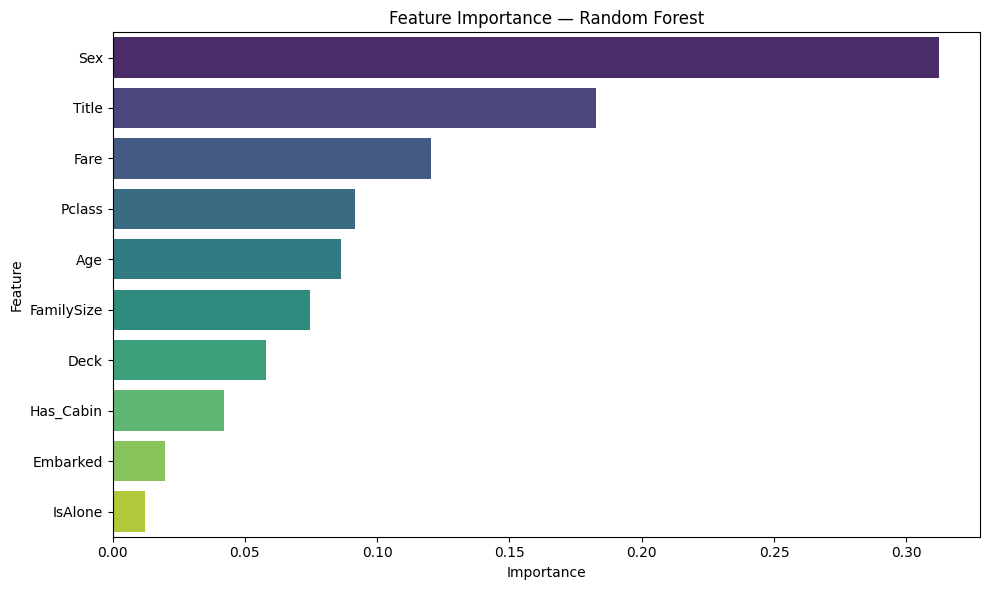

In [13]:

# Берём лучшие параметры из GridSearch:
best_model = grid_search.best_estimator_

# Обучаем на ВСЁМ train:
best_model.fit(X_train, y_train)

# Важность признаков:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("=== ВАЖНОСТЬ ПРИЗНАКОВ ===")
print(feature_importance)

# Визуализация:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

In [14]:

predictions = best_model.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': predictions.astype(int)
})

print(f"Строк: {len(submission)}")
print(f"Пропуски: {submission.isnull().sum().sum()}")
print(f"Уникальные значения: {submission['Survived'].unique()}")
print(f"\nРаспределение предсказаний:")
print(submission['Survived'].value_counts())
print(f"\nПервые 10 строк:")
print(submission.head(10))


submission.to_csv('submission.csv', index=False)
print("\n✅ submission.csv готов!")

Строк: 418
Пропуски: 0
Уникальные значения: [0 1]

Распределение предсказаний:
Survived
0    267
1    151
Name: count, dtype: int64

Первые 10 строк:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0

✅ submission.csv готов!


In [15]:
# Проверь что формат совпадает:
gender_submission = pd.read_csv('data/gender_submission.csv')
print("Наш submission:")
print(submission.head(3))
print("\ngender_submission:")
print(gender_submission.head(3))

Наш submission:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0

gender_submission:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0


In [16]:

import joblib

# Сохраняем обученную модель:
joblib.dump(best_model, 'best_model.pkl')
print("✅ Модель сохранена!")

# Проверяем что сохранилась:
loaded_model = joblib.load('best_model.pkl')
test_predictions = loaded_model.predict(X_test)
print(f"✅ Модель загружена и работает!")
print(f"Предсказаний: {len(test_predictions)}")

✅ Модель сохранена!
✅ Модель загружена и работает!
Предсказаний: 418
